# Building a Basic Neural Network: NumPy vs PyTorch

The previous post covered a linear regression model. This time, we implement the most basic form of neural network (a 2-layer NN: one hidden layer + one output layer) to classify **data that isn't linearly separable**, using two different approaches:

1. **NumPy**: implement forward propagation and backpropagation directly from the equations
2. **PyTorch**: implement the same architecture using `autograd`

By comparing how both implementations solve the same problem, we'll walk through the core steps of training a neural network — forward pass → compute loss → backpropagation → parameter update — along with the underlying math.

## 1. Data: Data That Isn't Linearly Separable (XOR Pattern)

To create a problem that simple linear/logistic regression can't solve, we generate 2D data in an XOR pattern. This kind of data can't be separated into two classes by a single straight line (a linear decision boundary), which nicely illustrates why a hidden layer is needed.

In [1]:
import numpy as np
np.set_printoptions(precision=4)

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set()

np.random.seed(0)


In [2]:
# Generate 2D data in an XOR pattern (4 clusters; diagonal clusters share the same class)
def make_xor_data(n_per_cluster=75, std=0.6):
    centers = np.array([[0, 0], [2, 2], [0, 2], [2, 0]])
    labels = np.array([0, 0, 1, 1])  # (0,0),(2,2) -> class 0 / (0,2),(2,0) -> class 1

    X_list, Y_list = [], []
    for center, label in zip(centers, labels):
        pts = center + std * np.random.randn(n_per_cluster, 2)
        X_list.append(pts)
        Y_list.append(np.full(n_per_cluster, label))

    X = np.vstack(X_list)
    Y = np.concatenate(Y_list)

    # shuffle
    perm = np.random.permutation(len(Y))
    return X[perm], Y[perm]

X, Y = make_xor_data()
print(f'X shape: {X.shape}, Y shape: {Y.shape}')


X shape: (300, 2), Y shape: (300,)


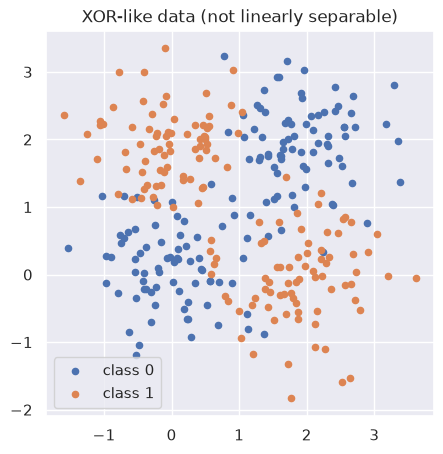

In [3]:
plt.figure(figsize=(5, 5))
plt.scatter(X[Y == 0, 0], X[Y == 0, 1], s=20, label='class 0')
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], s=20, label='class 1')
plt.title('XOR-like data (not linearly separable)')
plt.legend()
plt.show()


## 2. Neural Network Architecture and Equations

We use the simplest possible architecture: **a neural network with a single hidden layer (2-layer NN)**.

- Input layer: 2 nodes ($x_1, x_2$)
- Hidden layer: $n_h$ nodes, activation function $\tanh$
- Output layer: 1 node, activation function sigmoid (outputs a binary classification probability)

### Forward Propagation

For a single sample:

$$ Z^{[1]} = W^{[1]} X + b^{[1]} $$

$$ A^{[1]} = \tanh\left(Z^{[1]}\right) $$

$$ Z^{[2]} = W^{[2]} A^{[1]} + b^{[2]} $$

$$ A^{[2]} = \hat{Y} = \sigma\left(Z^{[2]}\right) = \frac{1}{1 + e^{-Z^{[2]}}} $$

Here, $W^{[1]} \in \mathbb{R}^{n_h \times 2}$ and $W^{[2]} \in \mathbb{R}^{1 \times n_h}$ are the trainable weights, and $b^{[1]}, b^{[2]}$ are the biases.

### Loss Function (Binary Cross-Entropy)

The average loss over $m$ samples:

$$ \mathcal{L} = -\frac{1}{m}\sum_{i=1}^{m}\Big[\,y^{(i)}\log a^{(2)(i)} + (1-y^{(i)})\log\left(1-a^{(2)(i)}\right)\Big] $$

### Backpropagation

Applying the chain rule, we compute the gradient of the loss with respect to each parameter. Using $\tanh'(z) = 1 - \tanh(z)^2$:

$$ dZ^{[2]} = A^{[2]} - Y $$

$$ dW^{[2]} = \frac{1}{m}\, dZ^{[2]} {A^{[1]}}^{T} $$

$$ db^{[2]} = \frac{1}{m}\sum dZ^{[2]} $$

$$ dZ^{[1]} = {W^{[2]}}^{T} dZ^{[2]} * \left(1 - \left(A^{[1]}\right)^2\right) $$

$$ dW^{[1]} = \frac{1}{m}\, dZ^{[1]} X^{T} $$

$$ db^{[1]} = \frac{1}{m}\sum dZ^{[1]} $$

### Parameter Update (Gradient Descent)

With learning rate $\alpha$:

$$ W^{[l]} := W^{[l]} - \alpha\, dW^{[l]} \qquad b^{[l]} := b^{[l]} - \alpha\, db^{[l]} $$

## 3. Implementing It Directly in NumPy

We translate the equations above directly into code. For convenience with matrix operations, the input is transposed into `(n_features, m_samples)` form.

In [4]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def initialize_parameters(n_x, n_h, n_y, seed=1):
    rng = np.random.RandomState(seed)
    W1 = rng.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = rng.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    return {'W1': W1, 'b1': b1, 'W2': W2, 'b2': b2}


In [5]:
def forward_propagation(X, params):
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']

    Z1 = W1 @ X + b1
    A1 = np.tanh(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)

    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2}
    return A2, cache


In [6]:
def compute_cost(A2, Y):
    m = Y.shape[1]
    eps = 1e-8  # avoid log(0)
    cost = -np.sum(Y * np.log(A2 + eps) + (1 - Y) * np.log(1 - A2 + eps)) / m
    return float(np.squeeze(cost))


In [7]:
def backward_propagation(params, cache, X, Y):
    m = X.shape[1]
    W2 = params['W2']
    A1, A2 = cache['A1'], cache['A2']

    dZ2 = A2 - Y
    dW2 = (dZ2 @ A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dZ1 = (W2.T @ dZ2) * (1 - np.power(A1, 2))
    dW1 = (dZ1 @ X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}


In [8]:
def update_parameters(params, grads, learning_rate):
    params = {
        'W1': params['W1'] - learning_rate * grads['dW1'],
        'b1': params['b1'] - learning_rate * grads['db1'],
        'W2': params['W2'] - learning_rate * grads['dW2'],
        'b2': params['b2'] - learning_rate * grads['db2'],
    }
    return params


In [9]:
def train_numpy_nn(X, Y, n_h=6, num_epochs=3000, learning_rate=0.5, seed=1):
    n_x, n_y = X.shape[0], Y.shape[0]
    params = initialize_parameters(n_x, n_h, n_y, seed=seed)

    costs = []
    for epoch in range(num_epochs):
        A2, cache = forward_propagation(X, params)
        cost = compute_cost(A2, Y)
        grads = backward_propagation(params, cache, X, Y)
        params = update_parameters(params, grads, learning_rate)

        costs.append(cost)
        if epoch % 500 == 0:
            print(f'Epoch {epoch:4d} | cost: {cost:.4f}')

    return params, costs

# reshape input into (n_features, m_samples) form
X_np = X.T
Y_np = Y.reshape(1, -1)

params_np, costs_np = train_numpy_nn(X_np, Y_np, n_h=6, num_epochs=3000, learning_rate=0.5)


Epoch    0 | cost: 0.6931
Epoch  500 | cost: 0.3177
Epoch 1000 | cost: 0.2482


Epoch 1500 | cost: 0.2331
Epoch 2000 | cost: 0.2384
Epoch 2500 | cost: 0.2134


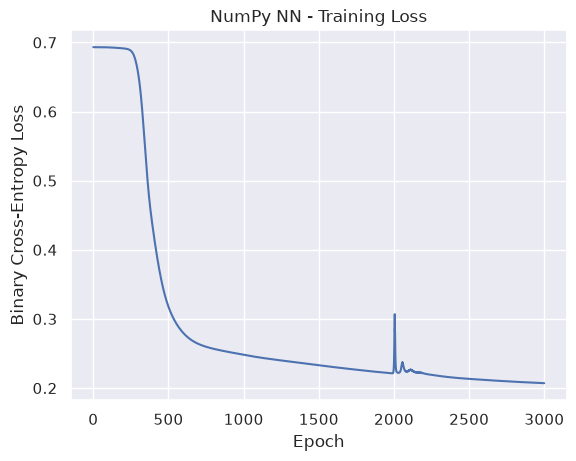

In [10]:
plt.plot(costs_np)
plt.title('NumPy NN - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.show()


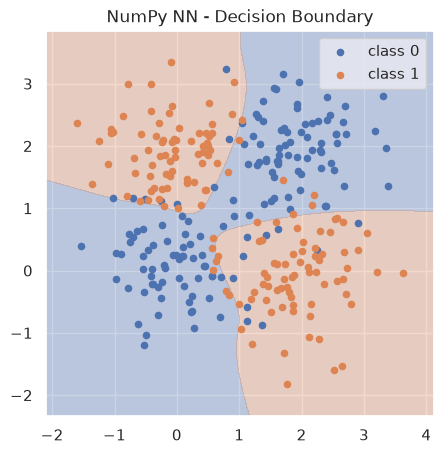

In [11]:
def plot_decision_boundary(predict_fn, X, Y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = predict_fn(grid).reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contourf(xx, yy, preds, levels=[0, 0.5, 1], alpha=0.3, colors=['#4C72B0', '#DD8452'])
    plt.scatter(X[Y == 0, 0], X[Y == 0, 1], s=20, label='class 0')
    plt.scatter(X[Y == 1, 0], X[Y == 1, 1], s=20, label='class 1')
    plt.title(title)
    plt.legend()
    plt.show()

def numpy_predict(grid_xy):
    A2, _ = forward_propagation(grid_xy.T, params_np)
    return A2.flatten()

plot_decision_boundary(numpy_predict, X, Y, 'NumPy NN - Decision Boundary')


In [12]:
train_acc_np = np.mean((params_np and forward_propagation(X_np, params_np)[0] > 0.5) == Y_np)
print(f'NumPy NN training accuracy: {train_acc_np * 100:.2f}%')


NumPy NN training accuracy: 89.33%


## 4. Implementing It in PyTorch

We define the same architecture (input 2 → hidden 6 with `tanh` → output 1 with `sigmoid`) as a PyTorch `nn.Module`, and let `autograd` compute the backward pass automatically. The equations we derived by hand for $dW^{[1]}, dW^{[2]}$, etc. are handled in PyTorch by a single call to `loss.backward()`.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(1)


In [14]:
class SimpleNN(nn.Module):
    def __init__(self, n_x=2, n_h=6, n_y=1):
        super().__init__()
        self.hidden = nn.Linear(n_x, n_h)
        self.output = nn.Linear(n_h, n_y)
        self.tanh = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        a1 = self.tanh(self.hidden(x))
        a2 = self.sigmoid(self.output(a1))
        return a2

model = SimpleNN(n_x=2, n_h=6, n_y=1)
print(model)


SimpleNN(
  (hidden): Linear(in_features=2, out_features=6, bias=True)
  (output): Linear(in_features=6, out_features=1, bias=True)
  (tanh): Tanh()
  (sigmoid): Sigmoid()
)


In [15]:
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32).view(-1, 1)

criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.5)


In [16]:
num_epochs = 3000
costs_torch = []

for epoch in range(num_epochs):
    model.train()

    outputs = model(X_tensor)
    loss = criterion(outputs, Y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    costs_torch.append(loss.item())
    if epoch % 500 == 0:
        print(f'Epoch {epoch:4d} | cost: {loss.item():.4f}')


Epoch    0 | cost: 0.7085
Epoch  500 | cost: 0.2610


Epoch 1000 | cost: 0.2341
Epoch 1500 | cost: 0.2212


Epoch 2000 | cost: 0.2150
Epoch 2500 | cost: 0.2115


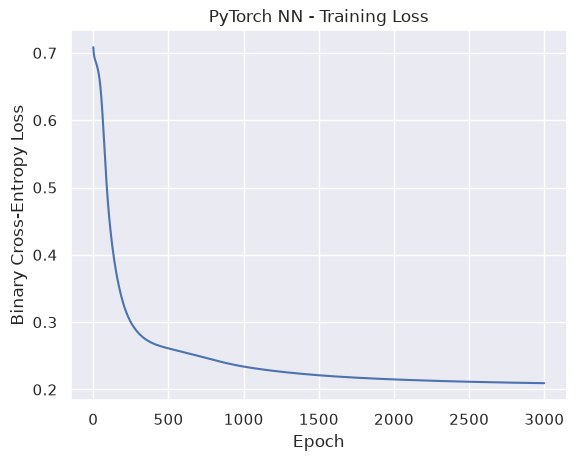

In [17]:
plt.plot(costs_torch)
plt.title('PyTorch NN - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.show()


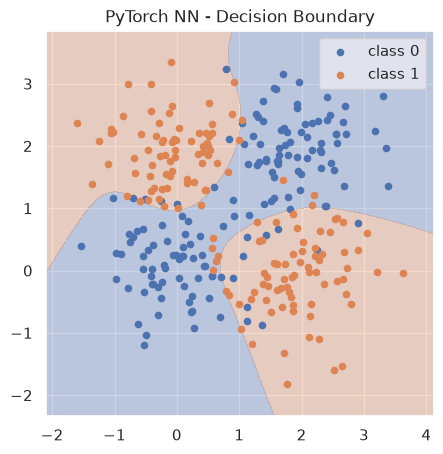

In [18]:
def torch_predict(grid_xy):
    model.eval()
    with torch.no_grad():
        preds = model(torch.tensor(grid_xy, dtype=torch.float32))
    return preds.numpy().flatten()

plot_decision_boundary(torch_predict, X, Y, 'PyTorch NN - Decision Boundary')


In [19]:
model.eval()
with torch.no_grad():
    train_acc_torch = ((model(X_tensor) > 0.5).float() == Y_tensor).float().mean().item()
print(f'PyTorch NN training accuracy: {train_acc_torch * 100:.2f}%')


PyTorch NN training accuracy: 89.67%


## 5. Summary

- Both implementations correctly classified the XOR-like data, which can't be separated by a single straight line, using a neural network with one hidden layer.
- The **NumPy implementation** translates the forward/backward propagation equations directly into code, which helps build an intuition for how gradients are computed and propagated inside a neural network.
- The **PyTorch implementation** lets `nn.Module` and `autograd` handle differentiation and parameter management, so the same model can be trained with much less code.
- Both implementations share the same core loop: **forward pass to predict → compute loss → backpropagation to compute gradients → gradient descent to update parameters**.